# Potencial de PDV — Categoría Sueros
### KOF (Ciudad de México) · Arca Continental (Guadalajara) · Bepensa (Mérida)

---

## Objetivo

Identificar y priorizar los puntos de venta con mayor **potencial de crecimiento** para la categoría
de Sueros en tres operaciones piloto, partiendo de la metodología estándar *Golden Stores*
(NielsenIQ · Spectra) y complementándola con la capa de relevancia geográfica de Scantrack.

## Metodología base (reconstruida de los entregables FY'23)

El modelo Golden Stores asigna a cada tienda **dos ejes**:

| Eje | Fuente | Qué mide |
|---|---|---|
| **Demanda potencial** | Spectra — sociodemográficos, compras del hogar, competidores, tiempo de manejo | Demanda latente del área transaccional de la tienda |
| **Ventas valor** | Scantrack — ventas valor/volumen del periodo | Desempeño real de la categoría en esa tienda |

El cruce produce el 2×2:

|  | **Venta alta** | **Venta baja** |
|---|---|---|
| **Demanda alta** | `HH` — **Golden Stores** | `HL` — **máxima brecha**: la demanda existe y no se captura |
| **Demanda baja** | `LH` — fortalecer | `LL` — bajo impacto |

Sobre ese clúster, las **líneas de reporte** llevan semáforo de desempeño
(`VERDE` / `AMARILLO` / `ROJO`): *T. Sueros* y *Electrolit + Suerox*.

## Los tres pasos solicitados

1. **Modelo base de segmentación** corrido para la categoría de Sueros → §4
2. **Perfilamiento de las Golden Stores** — qué tienen en común (entorno, perfil comercial,
   ubicación) — y extrapolación al resto del universo vía **Índice de Afinidad Sueros (IAS)** → §5
3. **Capa Scantrack** de relevancia geográfica por ciudad como ponderador → §6

Se consolida en un **Score de Potencial** (§7) y una síntesis ejecutiva (§8).

---

## Alcance y limitaciones — leer antes de interpretar cualquier número

La data disponible es un **corte transversal tienda × entorno**, no un log transaccional.
Esto acota de forma dura qué se puede calcular:

**Sí se puede** (y se hace aquí): perfilado socio-demográfico del área transaccional, segmentación,
modelo de afinidad *look-alike*, concentración tipo Pareto, priorización geográfica.

**No se puede** con esta data, y por eso no aparece: RFM y curvas de retención, market basket,
elasticidad-precio, descomposición temporal (STL, ADF/KPSS), GMROI. Todo eso exige transacciones o
series de venta por SKU y periodo. Fabricar esos números con la data actual sería inventarlos.

**Las ventas entran sólo como variable ordinal**, no cardinal: el archivo trae la *letra* del
clúster (segundo carácter = eje de venta) y el semáforo, no el valor de venta por tienda. Por eso
el potencial se construye sobre rangos y no sobre pesos.

---
## 0 · Setup y parámetros

In [10]:
from pathlib import Path
import re, unicodedata, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.covariance import MinCovDet
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (9, 4.5), "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 9})

SEMILLA = 42
PAL = {"HH": "#1b7f5a", "HL": "#d98c00", "LH": "#3b6fb6", "LL": "#9aa0a6"}
SEM_COLOR = {"VERDE": "#1b7f5a", "AMARILLO": "#d98c00", "ROJO": "#c0392b"}

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = RAIZ / "data"
OUT = RAIZ / "outputs"; OUT.mkdir(exist_ok=True)

# --- Operaciones piloto: Zona Metropolitana (como viene en Nielsen) -> embotellador
OPERACIONES = {
    "VALLE DE MEXICO": "KOF — Ciudad de México",
    "GUADALAJARA":     "Arca Continental — Guadalajara",
    "MERIDA":          "Bepensa — Mérida",
}

# --- Pesos del score de potencial (media geométrica ponderada, suman 1)
W_AFINIDAD = 0.50   # que tan parecida es la tienda a una Golden Store
W_BRECHA   = 0.30   # cuanto de esa demanda NO se esta capturando hoy
W_CIUDAD   = 0.20   # relevancia de la ciudad en la categoria (Scantrack)

# --- Desempeno actual implicito en el semaforo de la linea de reporte
ESCALA_SEMAFORO = {"VERDE": 1.0, "AMARILLO": 0.5, "ROJO": 0.0}

print(f"raíz    : {RAIZ}")
print(f"data    : {DATA}  ({'OK' if DATA.exists() else 'NO ENCONTRADA'})")
print(f"outputs : {OUT}")

raíz    : c:\Users\KIN\Desktop\Kin\eda_data
data    : c:\Users\KIN\Desktop\Kin\eda_data\data  (OK)
outputs : c:\Users\KIN\Desktop\Kin\eda_data\outputs


---
# 1 · Ingesta e integridad de datos

> *retail-math-eda §1 — estructura, grano, llave primaria, mecanismo de faltantes, anomalías estructurales.*

Los tres libros Golden Stores comparten layout: **header de dos niveles** (fila 8 = grupo
demográfico, fila 9 = métrica), datos desde la fila 10, y ~20 bloques `HHs / % / Índice` de perfil
del área transaccional.

**Grano declarado: una fila = un punto de venta (`Nielsen ID`).** Se verifica, no se asume.

In [11]:
FUENTES = [
    ("GS Hidratación R. Norte/Golden Stores Hidratación R.Norte - KO FY'23.xlsx",
     0, "GCA R.Norte", "Autoservicios"),
    ("GS Sueros Farmacias Nacional/Golden Stores Sueros Pharma Nacional - KO FY'23.xlsx",
     0, "T.Nacional Pharma", "Farmacias"),
    ("GS Sueros GCA R.Sur/Golden Stores Sueros R.Sur - KO FY'23.xlsx",
     0, "GCA R.Sur", "Autoservicios"),
]

def _norm(s):
    """Quita acentos y colapsa espacios: los headers vienen con acentuación inconsistente."""
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode()
    return re.sub(r"\s+", " ", s).strip()

def leer_gs(ruta, hoja, fuente, canal, fila_grupo=8, fila_campo=9):
    """Aplana el header de 2 niveles -> 'Grupo|Metrica' y devuelve el DataFrame de PDV."""
    wb = openpyxl.load_workbook(ruta, read_only=True, data_only=True)
    ws = wb.worksheets[hoja] if isinstance(hoja, int) else wb[hoja]
    g, h = [list(r) for r in ws.iter_rows(min_row=fila_grupo, max_row=fila_campo, values_only=True)]
    wb.close()

    ATRIB, cols, grupo = {"HHs", "%", "Indice"}, [], ""
    for a, b in zip(g, h):
        if a is not None:
            grupo = _norm(a)
        campo = _norm(b) if b is not None else ""
        cols.append(f"{grupo}|{campo}" if campo in ATRIB else campo)

    df = pd.read_excel(ruta, sheet_name=hoja, header=None, skiprows=fila_campo, names=cols)
    df = df.loc[:, [c for c in df.columns if c != ""]]
    # El nombre del cluster y de la cadena cambia por archivo ("Cluster Hidratación", "Cadena de Farmacias"...)
    df = df.rename(columns={c: "Cluster" for c in df.columns if c.startswith("Cluster")})
    df = df.rename(columns={c: "Cadena"  for c in df.columns if c.startswith("Cadena de")})
    return df.dropna(subset=["Nielsen ID"]).assign(fuente=fuente, canal=canal)

partes = [leer_gs(DATA / r, h, f, c) for r, h, f, c in FUENTES]
for p_, (_, _, f, _) in zip(partes, FUENTES):
    sem = [c for c in p_.columns if c in ("Sueros", "T. Sueros", "Electrolit + Suerox")]
    print(f"{f:20s} {p_.shape[0]:>5,} PDV × {p_.shape[1]:>3} cols   semáforos sueros: {sem}")

GCA R.Norte          1,768 PDV ×  81 cols   semáforos sueros: ['Sueros']
T.Nacional Pharma    5,676 PDV ×  81 cols   semáforos sueros: ['T. Sueros', 'Electrolit + Suerox']
GCA R.Sur            1,420 PDV ×  80 cols   semáforos sueros: ['T. Sueros', 'Electrolit + Suerox']


### 1.1 · Unificación del semáforo de Sueros

El semáforo de la categoría se llama distinto según el libro: `Sueros` en Hidratación R.Norte
(donde Sueros es línea de reporte secundaria) y `T. Sueros` en los dos libros cuyo target *es*
Sueros. Se unifican en `sem_sueros`, conservando la procedencia.

In [12]:
univ = pd.concat(partes, ignore_index=True)

univ["sem_sueros"] = univ["T. Sueros"] if "T. Sueros" in univ else np.nan
univ["sem_sueros"] = univ["sem_sueros"].fillna(univ["Sueros"]) if "Sueros" in univ else univ["sem_sueros"]
univ["sem_electrolit"] = univ["Electrolit + Suerox"] if "Electrolit + Suerox" in univ else np.nan
univ["Cluster"] = univ["Cluster"].astype(str).str.strip().str.upper()

# Ejes del modelo base, decodificados de la letra del cluster
univ["demanda_potencial"] = univ["Cluster"].str[0].map({"H": "Alta", "L": "Baja"})
univ["venta_valor"]       = univ["Cluster"].str[1].map({"H": "Alta", "L": "Baja"})

print(f"Universo consolidado: {len(univ):,} filas × {univ.shape[1]} columnas\n")
print(univ.groupby(["fuente", "canal"]).size().to_frame("PDV"))
print("\nCobertura del semáforo de Sueros:")
print(univ.groupby("fuente").sem_sueros.apply(lambda s: f"{s.notna().mean()*100:.0f}%").to_frame("con semáforo"))

Universo consolidado: 8,864 filas × 88 columnas

                                  PDV
fuente            canal              
GCA R.Norte       Autoservicios  1768
GCA R.Sur         Autoservicios  1420
T.Nacional Pharma Farmacias      5676

Cobertura del semáforo de Sueros:
                  con semáforo
fuente                        
GCA R.Norte               100%
GCA R.Sur                 100%
T.Nacional Pharma         100%


### 1.2 · Censo de integridad

In [13]:
llave = "Nielsen ID"
dup = univ.duplicated(llave).sum()
print(f"Grano  : 1 fila = 1 PDV")
print(f"Llave  : '{llave}' — {univ[llave].nunique():,} únicos sobre {len(univ):,} filas → "
      f"{'ÚNICA ✔' if dup == 0 else f'{dup} DUPLICADOS ✘'}")

fuera = ~(univ.Latitud.between(14, 33) & univ.Longitud.between(-118, -86))
print(f"Geo    : {univ[['Latitud','Longitud']].isna().sum().sum()} nulos · "
      f"{int(fuera.sum())} fuera del bounding box de México")

crit = [c for c in ["Cluster", "sem_sueros", "Cadena", "Zonas Metropolitanas", "Estado", "Municipio"]
        if c in univ.columns]
display(pd.DataFrame({"nulos": univ[crit].isna().sum(),
                      "% nulos": (univ[crit].isna().mean() * 100).round(2),
                      "únicos": univ[crit].nunique()}))

Grano  : 1 fila = 1 PDV
Llave  : 'Nielsen ID' — 8,864 únicos sobre 8,864 filas → ÚNICA ✔
Geo    : 0 nulos · 0 fuera del bounding box de México


,nulos,% nulos,únicos
Cluster,0,0.0,4
sem_sueros,0,0.0,3
Cadena,0,0.0,39
Zonas Metropolitanas,0,0.0,60
Estado,0,0.0,32
Municipio,0,0.0,902


**Lectura del mecanismo de faltantes (MCAR / MAR / MNAR).**

`Colonia` en blanco es **MAR**: son plazas y centros comerciales sin colonia catastral asignada,
no un error de captura — se codifica como `SIN COLONIA` en lugar de imputarse.

`Electrolit + Suerox` nulo es **estructural, no faltante**: el libro de Hidratación R.Norte no
reporta esa línea porque su target es Agua. Imputarlo mezclaría universos distintos; se deja nulo
y se excluye de cualquier modelo que cruce las tres fuentes.

`Saturación Farmacias independientes` sólo existe en el libro de farmacias — es atributo de canal,
no variable universal.

In [14]:
univ["Colonia"] = univ["Colonia"].fillna("SIN COLONIA").replace(r"^\s*$", "SIN COLONIA", regex=True)

n = univ.isna().sum()
print("Columnas con al menos un faltante:")
display(n[n > 0].sort_values(ascending=False).to_frame("nulos")
        .assign(**{"% del universo": lambda d: (d.nulos / len(univ) * 100).round(1)}))

Columnas con al menos un faltante:


,nulos,% del universo
Agua natural hasta 10.1L,7096,80.1
Agua mineral,7096,80.1
Sueros,7096,80.1
Saturacion Farmacias independientes,3188,36.0
Electrolit + Suerox,1768,19.9
T. Sueros,1768,19.9
sem_electrolit,1768,19.9
Codigo Postal,2,0.0


### 1.3 · Cobertura de las tres operaciones piloto

In [15]:
cob = (univ[univ["Zonas Metropolitanas"].isin(OPERACIONES)]
       .pivot_table(index="Zonas Metropolitanas", columns="fuente",
                    values="Nielsen ID", aggfunc="count", fill_value=0))
cob["TOTAL"] = cob.sum(axis=1)
cob.index = [OPERACIONES[i] for i in cob.index]
display(cob)

print(f"\nPDV en las 3 operaciones piloto: {cob.TOTAL.sum():,} "
      f"({cob.TOTAL.sum()/len(univ)*100:.1f}% del universo nacional de {len(univ):,})")

fuente,GCA R.Norte,GCA R.Sur,T.Nacional Pharma,TOTAL
Arca Continental — Guadalajara,103,0,174,277
Bepensa — Mérida,0,65,149,214
KOF — Ciudad de México,0,462,641,1103



PDV en las 3 operaciones piloto: 1,594 (18.0% del universo nacional de 8,864)


> **Nota de cobertura — restricción real del piloto.**
> Ninguna fuente cubre las tres ciudades por sí sola: Guadalajara aparece en Autoservicios R.Norte
> y en Farmacias; CDMX y Mérida en Autoservicios R.Sur y Farmacias. La consolidación de las tres
> fuentes es lo que hace viable el ejercicio, y por eso **los modelos se entrenan sobre el universo
> nacional y se aplican a las tres ciudades**: entrenar sólo con las ~1.6k tiendas de las tres
> plazas desperdiciaría el resto de la señal y sobreajustaría a su mix de cadenas.

---
# 2 · Análisis univariado y colas pesadas

> *retail-math-eda §2 — momentos, estadísticos robustos, colas pesadas, cero-inflación.*

Los **índices Spectra** están construidos con base 100 = promedio nacional: un índice de 130 en
`A/B` significa que el área transaccional de esa tienda tiene 30% más hogares A/B que el promedio.
Ese anclaje es lo que los hace comparables entre ciudades, y el motivo por el que se modela sobre
índices y no sobre conteos de hogares (que sólo reflejarían el tamaño del polígono).

In [16]:
IDX = [c for c in univ.columns if c.endswith("|Indice")]
HHS = [c for c in univ.columns if c.endswith("|HHs")]
print(f"{len(IDX)} índices demográficos · {len(HHS)} conteos de hogares")

def univariado(s):
    x = pd.to_numeric(s, errors="coerce").dropna().to_numpy(float)
    if len(x) < 30:
        return None
    q1, q3 = np.percentile(x, [25, 75])
    return dict(n=len(x), media=x.mean(), mediana=np.median(x), desv=x.std(ddof=1),
                CV=x.std(ddof=1) / x.mean() if x.mean() else np.nan,
                IQR=q3 - q1, MAD=stats.median_abs_deviation(x, scale="normal"),
                sesgo=stats.skew(x), curtosis_exc=stats.kurtosis(x),
                p5=np.percentile(x, 5), p95=np.percentile(x, 95))

resumen = pd.DataFrame({c.replace("|Indice", ""): univariado(univ[c]) for c in IDX}).T
display(resumen.round(2))

20 índices demográficos · 20 conteos de hogares


,n,media,mediana,desv,CV,IQR,MAD,sesgo,curtosis_exc,p5,p95
2 o Menos Personas,8864.0,99.41,99.0,17.05,0.17,24.0,17.79,0.26,-0.27,73.0,128.0
3 personas,8864.0,100.30,100.5,6.39,0.06,8.0,6.67,-0.20,0.55,91.0,111.0
4 personas,8864.0,99.57,100.0,8.28,0.08,11.0,8.90,0.02,-0.06,86.0,114.0
5 personas,8864.0,101.90,102.0,11.93,0.12,17.0,11.86,0.14,-0.24,83.0,122.0
6+ personas,8864.0,99.54,97.0,20.82,0.21,28.0,20.76,0.69,0.02,71.0,141.0
Nino < 6,8864.0,101.17,100.0,10.55,0.10,14.0,10.38,0.54,-0.24,86.0,121.0
Nino 6 - 11,8864.0,101.84,103.0,10.31,0.10,14.0,10.38,-0.32,-0.51,83.0,117.0
Nino 12+,8864.0,101.98,103.0,11.49,0.11,15.0,11.86,-0.32,-0.07,80.0,119.0
Sin Ninos,8864.0,98.07,97.0,10.87,0.11,14.0,10.38,0.55,-0.02,83.0,119.0
Edad menos de 35,8864.0,102.21,101.0,15.65,0.15,17.0,13.34,0.79,1.28,78.0,130.0


2/20 variables con cola pesada (|sesgo| > 1 o curtosis excedente > 3):


,media,mediana,sesgo,curtosis_exc,p95
D+,100.28,103.0,0.30,4.22,136.0
A/B,96.85,76.0,1.33,1.44,251.0


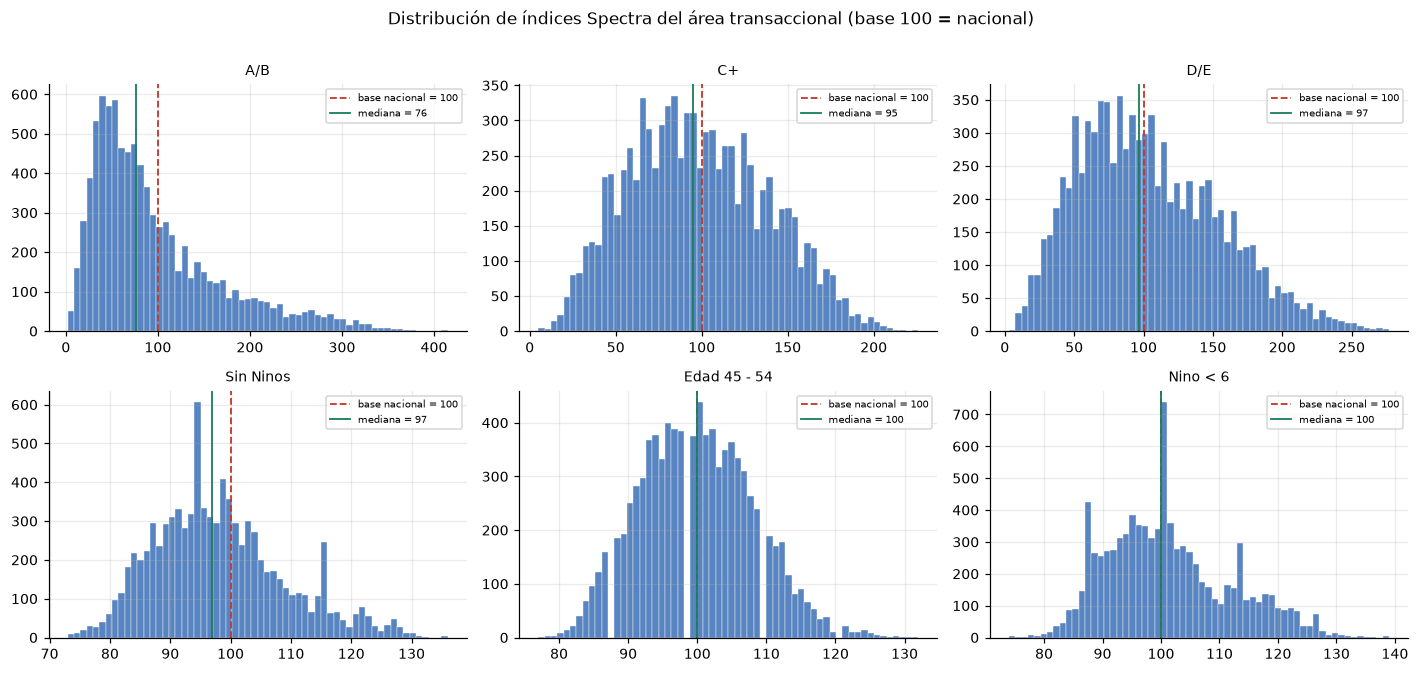

In [17]:
# El sesgo y la curtosis dicen que estos indices NO son gaussianos: hay areas transaccionales
# extremadamente sobre-indexadas que arrastran la cola derecha.
pesados = resumen[(resumen.sesgo.abs() > 1) | (resumen.curtosis_exc > 3)].sort_values(
    "curtosis_exc", ascending=False)
print(f"{len(pesados)}/{len(resumen)} variables con cola pesada (|sesgo| > 1 o curtosis excedente > 3):")
display(pesados[["media", "mediana", "sesgo", "curtosis_exc", "p95"]].round(2))

objetivo = [c for c in ["A/B|Indice", "C+|Indice", "D/E|Indice", "Sin Ninos|Indice",
                        "Edad 45 - 54|Indice", "Nino < 6|Indice"] if c in univ.columns]
fig, ax = plt.subplots(2, 3, figsize=(13, 6))
for a, c in zip(ax.ravel(), objetivo):
    v = pd.to_numeric(univ[c], errors="coerce").dropna()
    a.hist(v, bins=60, color="#3b6fb6", alpha=.85, edgecolor="white", linewidth=.3)
    a.axvline(100, color="#c0392b", ls="--", lw=1.2, label="base nacional = 100")
    a.axvline(v.median(), color="#1b7f5a", lw=1.2, label=f"mediana = {v.median():.0f}")
    a.set_title(c.replace("|Indice", ""), fontsize=9); a.legend(fontsize=6.5)
fig.suptitle("Distribución de índices Spectra del área transaccional (base 100 = nacional)", y=1.01)
fig.tight_layout(); plt.show()

In [18]:
# Cola derecha: estimador de Hill sobre el 10% superior.
# alpha < 2 => varianza infinita en el limite: la media deja de ser un resumen honesto.
def hill(x, frac=.10):
    x = np.sort(np.asarray(x, float)); x = x[x > 0]
    k = max(10, int(len(x) * frac))
    cola = x[-k:]
    return k / np.sum(np.log(cola / cola[0])) if cola[0] > 0 else np.nan

tail = pd.Series({c.replace("|Indice", ""): hill(pd.to_numeric(univ[c], errors="coerce").dropna())
                  for c in IDX}).sort_values()
print("Índice de cola de Hill (α menor = cola más pesada):")
display(tail.round(2).to_frame("α_Hill").head(8))
print("Ninguna α cae por debajo de 2 → las medias siguen siendo resúmenes utilizables,\n"
      "pero los cortes de priorización se hacen sobre percentiles, no sobre medias.")

Índice de cola de Hill (α menor = cola más pesada):


,α_Hill
A/B,4.35
D/E,7.24
D+,8.10
C,8.60
Edad menos de 35,8.99
C-,9.28
C+,10.31
6+ personas,11.47


Ninguna α cae por debajo de 2 → las medias siguen siendo resúmenes utilizables,
pero los cortes de priorización se hacen sobre percentiles, no sobre medias.


---
# 3 · Dependencias multivariadas

> *retail-math-eda §3 — correlación lineal y de rangos con control de FDR, PCA, outliers multivariados.*

Con 20 índices se corren **190 pruebas pareadas**. Reportar p-values crudos ahí produce ~10 falsos
positivos por puro azar, así que se controla la tasa de descubrimientos falsos con
**Benjamini-Hochberg** y se reportan q-values.

In [19]:
def panel_dependencias(df, cols, alpha=.05):
    X = df[cols].apply(pd.to_numeric, errors="coerce").dropna()
    filas = []
    for i, a in enumerate(cols):
        for b in cols[i + 1:]:
            rp, _ = stats.pearsonr(X[a], X[b])
            rs, ps = stats.spearmanr(X[a], X[b])
            filas.append((a.replace("|Indice", ""), b.replace("|Indice", ""), rp, rs, ps))
    r = pd.DataFrame(filas, columns=["var_a", "var_b", "pearson", "spearman", "p"])
    r["q_BH"] = stats.false_discovery_control(r.p.clip(1e-300), method="bh")
    r["signif"] = r.q_BH < alpha
    return r.sort_values("spearman", key=abs, ascending=False)

dep = panel_dependencias(univ, IDX)
print(f"{len(dep)} pares evaluados · {int(dep.signif.sum())} significativos tras control BH de FDR (q<0.05)")
print("\nRelaciones monotónicas más fuertes:")
display(dep.head(12).round(3))

190 pares evaluados · 179 significativos tras control BH de FDR (q<0.05)

Relaciones monotónicas más fuertes:


,var_a,var_b,pearson,spearman,p,q_BH,signif
183,C+,D/E,-0.917,-0.940,0.0,0.0,True
112,Nino 12+,Sin Ninos,-0.944,-0.927,0.0,0.0,True
175,A/B,C+,0.873,0.923,0.0,0.0,True
179,A/B,D/E,-0.780,-0.873,0.0,0.0,True
178,A/B,D+,-0.821,-0.842,0.0,0.0,True
3,2 o Menos Personas,6+ personas,-0.796,-0.836,0.0,0.0,True
100,Nino 6 - 11,Sin Ninos,-0.853,-0.826,0.0,0.0,True
137,Edad menos de 35,Edad 55 - 64,-0.785,-0.820,0.0,0.0,True
2,2 o Menos Personas,5 personas,-0.809,-0.806,0.0,0.0,True
155,Edad 45 - 54,Edad 65+,-0.730,-0.762,0.0,0.0,True


In [20]:
# La brecha |Spearman| - |Pearson| delata relaciones no lineales que una correlacion lineal subestima.
dep["brecha_lineal"] = dep.spearman.abs() - dep.pearson.abs()
print("Pares donde la relación es claramente no lineal (Spearman >> Pearson):")
display(dep.nlargest(8, "brecha_lineal")[["var_a", "var_b", "pearson", "spearman",
                                          "brecha_lineal", "q_BH"]].round(3))
print("\nEsto justifica probar un modelo no lineal (gradient boosting) frente a la logística en §5.2.")

Pares donde la relación es claramente no lineal (Spearman >> Pearson):


,var_a,var_b,pearson,spearman,brecha_lineal,q_BH
176,A/B,C,0.119,0.286,0.168,0.0
189,D+,D/E,0.607,0.712,0.105,0.0
179,A/B,D/E,-0.780,-0.873,0.093,0.0
38,4 personas,6+ personas,0.344,0.416,0.072,0.0
173,Edad 65+,D+,0.233,0.304,0.071,0.0
185,C,D+,-0.175,-0.245,0.070,0.0
84,6+ personas,D/E,-0.047,-0.115,0.068,0.0
169,Edad 65+,A/B,-0.253,-0.317,0.065,0.0



Esto justifica probar un modelo no lineal (gradient boosting) frente a la logística en §5.2.


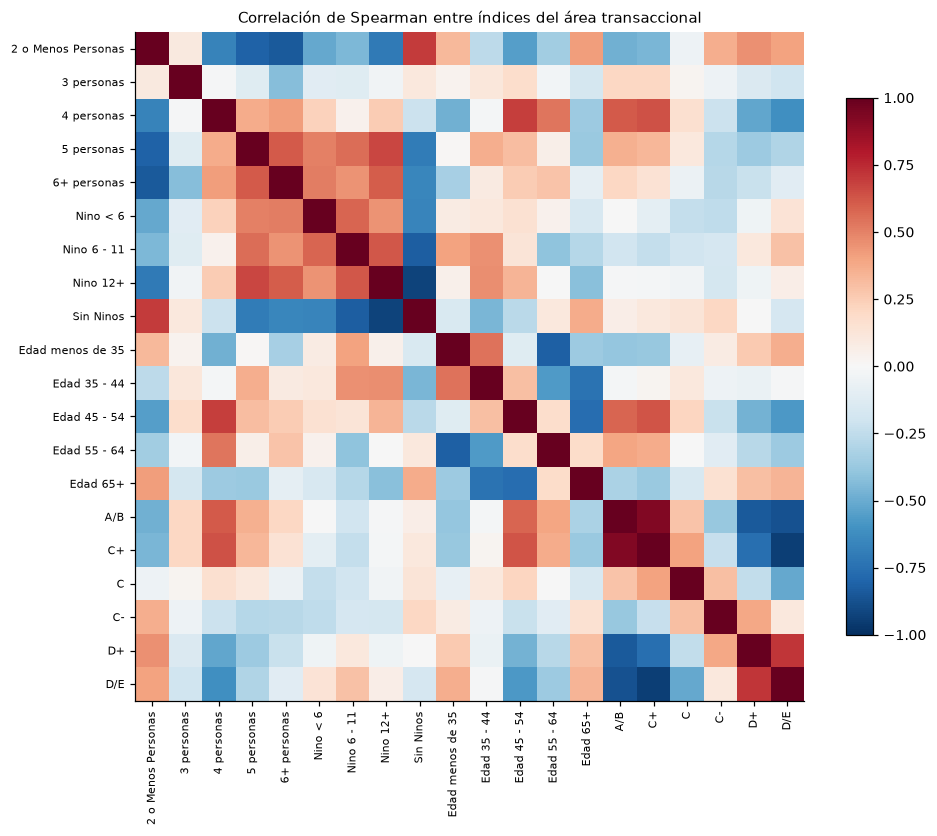

In [21]:
M = univ[IDX].apply(pd.to_numeric, errors="coerce").corr(method="spearman")
M.index = M.columns = [c.replace("|Indice", "") for c in IDX]

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(M, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(M))); ax.set_xticklabels(M.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(M))); ax.set_yticklabels(M.index, fontsize=7)
ax.set_title("Correlación de Spearman entre índices del área transaccional", fontsize=10)
ax.grid(False); fig.colorbar(im, shrink=.8); fig.tight_layout(); plt.show()

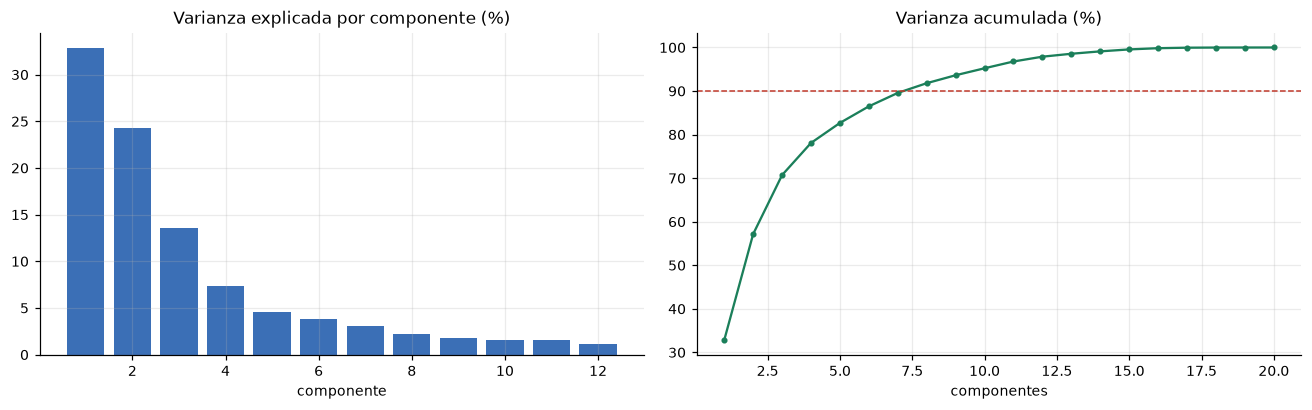

8 componentes explican el 90% de la varianza: los 20 índices describen, en realidad, ~8 ejes independientes de entorno.

Variables que más pesan en cada eje principal:
  PC1 (32.8%): 2 o Menos Personas, 5 personas, 4 personas, Edad 45 - 54
  PC2 (24.3%): Nino 6 - 11, Sin Ninos, Nino 12+, D/E
  PC3 (13.5%): Edad 65+, Edad menos de 35, Edad 35 - 44, 6+ personas


In [22]:
# PCA sobre indices estandarizados: cuantas dimensiones reales tiene el perfil de entorno.
Xs = StandardScaler().fit_transform(univ[IDX].apply(pd.to_numeric, errors="coerce").fillna(100))
pca = PCA(random_state=SEMILLA).fit(Xs)
ev = pca.explained_variance_ratio_
k90 = int(np.argmax(np.cumsum(ev) >= .90) + 1)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8))
a1.bar(range(1, 13), ev[:12] * 100, color="#3b6fb6")
a1.set_title("Varianza explicada por componente (%)"); a1.set_xlabel("componente")
a2.plot(range(1, len(ev) + 1), np.cumsum(ev) * 100, "o-", color="#1b7f5a", ms=3)
a2.axhline(90, color="#c0392b", ls="--", lw=1)
a2.set_title("Varianza acumulada (%)"); a2.set_xlabel("componentes")
fig.tight_layout(); plt.show()

print(f"{k90} componentes explican el 90% de la varianza: los {len(IDX)} índices describen, "
      f"en realidad, ~{k90} ejes independientes de entorno.")

carga = pd.DataFrame(pca.components_[:3].T, index=[c.replace("|Indice", "") for c in IDX],
                     columns=["PC1", "PC2", "PC3"])
print("\nVariables que más pesan en cada eje principal:")
for i, pc in enumerate(["PC1", "PC2", "PC3"]):
    print(f"  {pc} ({ev[i]*100:4.1f}%): {', '.join(carga[pc].abs().nlargest(4).index)}")

In [23]:
# Outliers multivariados: distancia de Mahalanobis robusta (MCD) contra el cutoff chi-cuadrado.
sub = univ[IDX].apply(pd.to_numeric, errors="coerce").fillna(100)
mcd = MinCovDet(random_state=SEMILLA, support_fraction=.85).fit(sub)
univ["mahalanobis_d2"] = mcd.mahalanobis(sub)
corte = stats.chi2.ppf(.999, df=len(IDX))
univ["entorno_atipico"] = univ.mahalanobis_d2 > corte

print(f"Corte χ²(gl={len(IDX)}, 0.999) = {corte:.1f}")
print(f"{int(univ.entorno_atipico.sum()):,} PDV ({univ.entorno_atipico.mean()*100:.1f}%) con entorno atípico\n")
print("Dónde están esos entornos atípicos:")
display(univ[univ.entorno_atipico].groupby(["canal", "Zonas Metropolitanas"]).size()
        .nlargest(8).to_frame("PDV atípicos"))

Corte χ²(gl=20, 0.999) = 45.3
791 PDV (8.9%) con entorno atípico

Dónde están esos entornos atípicos:


PDV atípicos
canal         Zonas Metropolitanas                                     
Farmacias     NON-METRO                                             209
Autoservicios NON-METRO                                              60
Farmacias     MONTERREY                                              48
Autoservicios SAN LUIS POTOSI SOLEDAD DE GRACIANO SANCHEZ            37
Farmacias     CANCUN                                                 33
              SAN LUIS POTOSI SOLEDAD DE GRACIANO SANCHEZ            30
              VALLE DE MEXICO                                        30
              GUADALAJARA                                            26

> **Los entornos atípicos no se eliminan.** En retail un outlier multivariado suele ser una tienda
> real y valiosa —aeropuertos, centrales de abasto, plazas turísticas— no un error de captura.
> Se marcan con `entorno_atipico` para que el ranking final sea auditable, y se conservan en el
> modelo. Descartarlos sesgaría el score justo en las tiendas de mayor tráfico.

---
# 4 · Modelo base de segmentación para Sueros

> **Paso 1 solicitado por el cliente.**

El clúster viene ya calculado en la fuente (`HH` / `HL` / `LH` / `LL`), producto del cruce
*demanda potencial × ventas valor*. Aquí se hacen tres cosas:

1. **Validar** que el eje de demanda del archivo es consistente con los índices demográficos —
   si no lo fuera, todo lo que sigue estaría construido sobre arena.
2. **Cuantificar** la distribución de cada cuadrante para la categoría Sueros.
3. **Cruzarlo con el semáforo** para separar *demanda no capturada* de *bajo potencial real*.

,PDV,% PDV,demanda,venta
Cluster,,,,
HH,1804,20.4,H,H
HL,2183,24.6,H,L
LH,1585,17.9,L,H
LL,3292,37.1,L,L


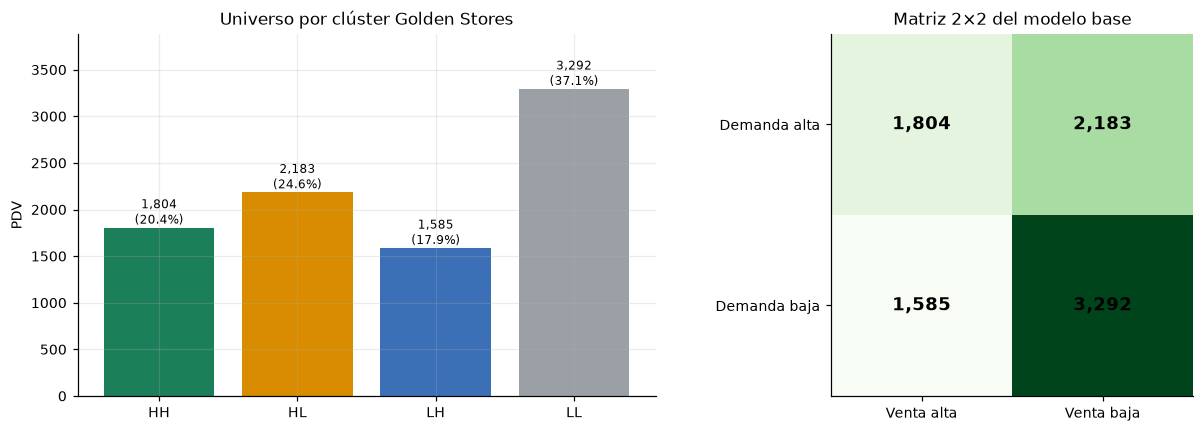

In [24]:
seg = (univ.groupby("Cluster").agg(PDV=("Nielsen ID", "count"))
       .assign(**{"% PDV": lambda d: (d.PDV / d.PDV.sum() * 100).round(1)}))
seg["demanda"] = [i[0] for i in seg.index]
seg["venta"] = [i[1] for i in seg.index]
display(seg)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.bar(seg.index, seg.PDV, color=[PAL[i] for i in seg.index])
for i, (k, v) in enumerate(seg.PDV.items()):
    a1.text(i, v, f"{v:,}\n({seg.loc[k,'% PDV']}%)", ha="center", va="bottom", fontsize=8)
a1.set_title("Universo por clúster Golden Stores"); a1.set_ylabel("PDV"); a1.margins(y=.18)

m = univ.pivot_table(index="demanda_potencial", columns="venta_valor",
                     values="Nielsen ID", aggfunc="count").reindex(
                     index=["Alta", "Baja"], columns=["Alta", "Baja"])
a2.imshow(m, cmap="Greens")
a2.set_xticks([0, 1], ["Venta alta", "Venta baja"])
a2.set_yticks([0, 1], ["Demanda alta", "Demanda baja"]); a2.grid(False)
for i in range(2):
    for j in range(2):
        a2.text(j, i, f"{m.iloc[i,j]:,}", ha="center", va="center", fontsize=12, fontweight="bold")
a2.set_title("Matriz 2×2 del modelo base")
fig.tight_layout(); plt.show()

In [25]:
# Validacion del eje de demanda: si el cluster esta bien construido, las tiendas de demanda Alta
# deben sobre-indexar en las variables que definen al target de Sueros.
alta = univ.demanda_potencial.eq("Alta")

def cohen_d(a, b):
    na, nb = len(a), len(b)
    sp = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (a.mean() - b.mean()) / sp if sp else 0.0

val = []
for c in IDX:
    x = pd.to_numeric(univ[c], errors="coerce")
    a, b = x[alta].dropna(), x[~alta].dropna()
    _, pv = stats.mannwhitneyu(a, b)
    val.append((c.replace("|Indice", ""), a.mean(), b.mean(), a.mean() - b.mean(), cohen_d(a, b), pv))

val = pd.DataFrame(val, columns=["variable", "idx_demanda_alta", "idx_demanda_baja",
                                 "delta", "cohen_d", "p"])
val["q_BH"] = stats.false_discovery_control(val.p.clip(1e-300), method="bh")
val = val.sort_values("cohen_d", key=abs, ascending=False)

print("¿El eje de demanda del archivo separa perfiles demográficos? (Mann-Whitney + BH-FDR)")
display(val.head(10).round(3))
print(f"\n{int((val.q_BH < .05).sum())}/{len(val)} índices separan significativamente los dos niveles "
      f"de demanda → el eje de demanda es consistente con los datos socio-demográficos ✔")

¿El eje de demanda del archivo separa perfiles demográficos? (Mann-Whitney + BH-FDR)


,variable,idx_demanda_alta,idx_demanda_baja,delta,cohen_d,p,q_BH
15,C+,110.727,87.535,23.192,0.604,0.0,0.0
11,Edad 45 - 54,102.464,97.761,4.703,0.597,0.0,0.0
2,4 personas,101.815,97.741,4.073,0.507,0.0,0.0
14,A/B,113.995,82.833,31.162,0.455,0.0,0.0
13,Edad 65+,93.226,101.940,-8.714,-0.440,0.0,0.0
19,D/E,92.909,112.927,-20.017,-0.405,0.0,0.0
0,2 o Menos Personas,95.713,102.430,-6.716,-0.402,0.0,0.0
10,Edad 35 - 44,102.977,99.988,2.989,0.297,0.0,0.0
18,D+,96.261,103.570,-7.309,-0.286,0.0,0.0
16,C,102.979,96.633,6.347,0.269,0.0,0.0



20/20 índices separan significativamente los dos niveles de demanda → el eje de demanda es consistente con los datos socio-demográficos ✔


Distribución del semáforo de Sueros dentro de cada clúster (% fila):


sem_sueros,VERDE,AMARILLO,ROJO
Cluster,,,
HH,19.9,46.2,33.9
HL,20.8,47.4,31.7
LH,24.5,48.2,27.3
LL,26.3,45.9,27.8


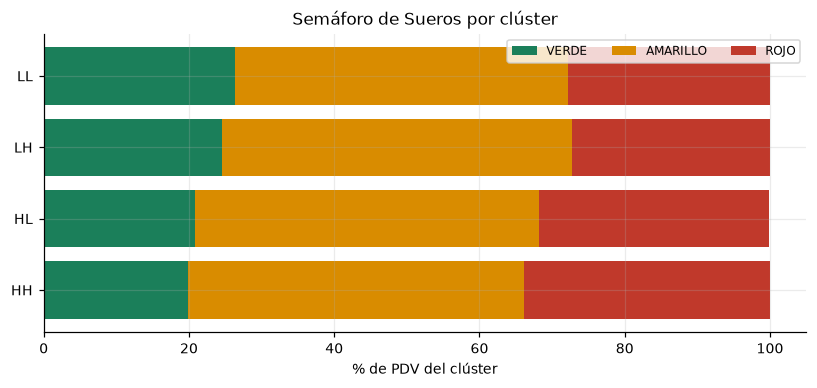


Bolsa de oportunidad más limpia: 693 PDV en clúster HL con semáforo ROJO — la demanda está medida y la categoría no se está vendiendo.


In [26]:
# Cruce cluster x semaforo: aqui se separa "demanda no capturada" de "bajo potencial real".
cs = pd.crosstab(univ.Cluster, univ.sem_sueros, normalize="index").mul(100).round(1)
cs = cs[[c for c in ["VERDE", "AMARILLO", "ROJO"] if c in cs.columns]]
print("Distribución del semáforo de Sueros dentro de cada clúster (% fila):")
display(cs)

fig, ax = plt.subplots(figsize=(7.5, 3.6))
base = np.zeros(len(cs))
for col in cs.columns:
    ax.barh(cs.index, cs[col], left=base, color=SEM_COLOR[col], label=col)
    base += cs[col].to_numpy()
ax.set_xlabel("% de PDV del clúster"); ax.legend(ncol=3, fontsize=8)
ax.set_title("Semáforo de Sueros por clúster")
fig.tight_layout(); plt.show()

hl_rojo = int(((univ.Cluster == "HL") & (univ.sem_sueros == "ROJO")).sum())
print(f"\nBolsa de oportunidad más limpia: {hl_rojo:,} PDV en clúster HL con semáforo ROJO — "
      f"la demanda está medida y la categoría no se está vendiendo.")

---
# 5 · Golden Stores: perfil e Índice de Afinidad Sueros (IAS)

> **Paso 2 solicitado por el cliente.**

**Definición operativa de Golden Store**, tomada literal de la metodología FY'23:
`Cluster == "HH"` — alta demanda potencial **y** alta venta valor.

El objetivo es doble: (a) describir **qué tienen en común**, y (b) convertir ese perfil en un score
continuo aplicable a **todo el universo**, incluidas las tiendas que hoy no son Golden.

In [27]:
univ["es_golden"] = univ.Cluster.eq("HH").astype(int)
print(f"Golden Stores (HH): {univ.es_golden.sum():,} de {len(univ):,} PDV "
      f"({univ.es_golden.mean()*100:.1f}% del universo)\n")
display(univ.groupby(["canal", "fuente"]).es_golden.agg(
    PDV="count", golden="sum", **{"% golden": lambda s: round(s.mean() * 100, 1)}))

Golden Stores (HH): 1,804 de 8,864 PDV (20.4% del universo)



PDV  golden  % golden
canal         fuente                                   
Autoservicios GCA R.Norte        1768     326      18.4
              GCA R.Sur          1420     332      23.4
Farmacias     T.Nacional Pharma  5676    1146      20.2

### 5.1 · Qué tienen en común: perfil demográfico discriminante

,variable,golden,resto,ratio,cohen_d,p,q_BH
15,C+,117.444,92.989,1.263,0.629,0.000,0.000
14,A/B,126.659,89.233,1.419,0.546,0.000,0.000
11,Edad 45 - 54,102.628,99.173,1.035,0.426,0.000,0.000
2,4 personas,102.248,98.890,1.034,0.411,0.000,0.000
12,Edad 55 - 64,101.420,98.606,1.029,0.337,0.000,0.000
16,C,105.003,98.078,1.071,0.293,0.000,0.000
8,Sin Ninos,100.568,97.433,1.032,0.290,0.000,0.000
4,6+ personas,101.394,99.061,1.024,0.112,0.000,0.000
1,3 personas,100.808,100.175,1.006,0.099,0.000,0.000
10,Edad 35 - 44,101.268,101.349,0.999,-0.008,0.754,0.754


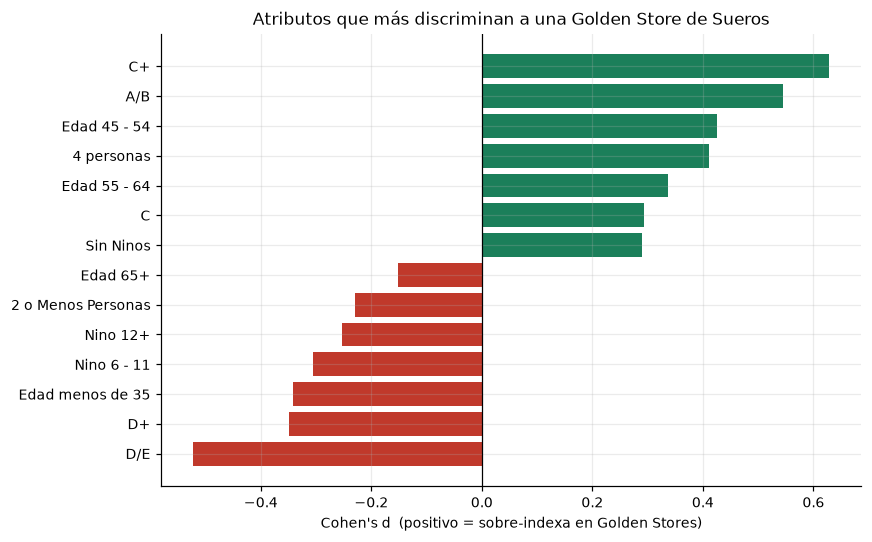

In [28]:
g, ng = univ.es_golden.eq(1), univ.es_golden.eq(0)
perfil = []
for c in IDX:
    x = pd.to_numeric(univ[c], errors="coerce")
    a, b = x[g].dropna(), x[ng].dropna()
    _, pv = stats.mannwhitneyu(a, b)
    perfil.append((c.replace("|Indice", ""), a.mean(), b.mean(), a.mean() / b.mean(),
                   cohen_d(a, b), pv))

perfil = pd.DataFrame(perfil, columns=["variable", "golden", "resto", "ratio", "cohen_d", "p"])
perfil["q_BH"] = stats.false_discovery_control(perfil.p.clip(1e-300), method="bh")
perfil = perfil.sort_values("cohen_d", ascending=False)
display(perfil.round(3))

top = pd.concat([perfil.head(7), perfil.tail(7)]).sort_values("cohen_d")
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top.variable, top.cohen_d, color=np.where(top.cohen_d > 0, "#1b7f5a", "#c0392b"))
ax.axvline(0, color="k", lw=.8)
ax.set_xlabel("Cohen's d  (positivo = sobre-indexa en Golden Stores)")
ax.set_title("Atributos que más discriminan a una Golden Store de Sueros")
fig.tight_layout(); plt.show()

In [29]:
# Perfil comercial y de ubicacion: cadena, canal y entorno urbano
def lift_categorico(col, minimo=40):
    t = univ.groupby(col).es_golden.agg(PDV="count", golden="sum")
    t = t[t.PDV >= minimo]
    t["% golden"] = (t.golden / t.PDV * 100).round(1)
    t["lift"] = (t.golden / t.PDV / univ.es_golden.mean()).round(2)
    return t.sort_values("lift", ascending=False)

print(f"CADENAS con mayor propensión a ser Golden Store (lift vs. base nacional de "
      f"{univ.es_golden.mean()*100:.1f}%):")
display(lift_categorico("Cadena").head(10))
print("\nCADENAS con menor propensión:")
display(lift_categorico("Cadena").tail(5))
print("\nZONA METROPOLITANA:")
display(lift_categorico("Zonas Metropolitanas", minimo=60).head(10))

CADENAS con mayor propensión a ser Golden Store (lift vs. base nacional de 20.4%):


,PDV,golden,% golden,lift
Cadena,,,,
CHEDRAUI SELECTO,42,28,66.7,3.28
HEB,83,52,62.7,3.08
WAL-MART,315,172,54.6,2.68
FARMACIAS - DEL AHORRO,1606,735,45.8,2.25
FARMACIAS - SAN PABLO,150,60,40.0,1.97
ALSUPER,81,29,35.8,1.76
WALMART EXPRESS,102,35,34.3,1.69
SORIANA MEGA,87,21,24.1,1.19
BODEGA AURRERA,592,133,22.5,1.10



CADENAS con menor propensión:


,PDV,golden,% golden,lift
Cadena,,,,
FARMACIAS - FARMAPRONTO,497,14,2.8,0.14
FARMACIAS - UNION,204,6,2.9,0.14
SORIANA MERCADO,163,1,0.6,0.03
MI BODEGA,473,1,0.2,0.01
SUPER SAN FCO DE ASIS,51,0,0.0,0.00



ZONA METROPOLITANA:


,PDV,golden,% golden,lift
Zonas Metropolitanas,,,,
TUXTLA GUTIERREZ,74,45,60.8,2.99
MORELIA,62,32,51.6,2.54
QUERETARO,102,48,47.1,2.31
SAN LUIS POTOSI SOLEDAD DE GRACIANO SANCHEZ,74,33,44.6,2.19
CANCUN,178,76,42.7,2.10
CUERNAVACA,97,38,39.2,1.92
AGUASCALIENTES,72,28,38.9,1.91
GUADALAJARA,277,107,38.6,1.90
XALAPA,70,27,38.6,1.90


### 5.2 · Índice de Afinidad Sueros (IAS)

Un modelo de propensión *look-alike*: aprende el entorno y el perfil comercial de las Golden Stores
y puntúa a **todas** las tiendas, incluidas las que hoy no venden.

**Guarda anti-fuga (crítica).** `Cluster`, `sem_sueros`, `venta_valor` y `demanda_potencial` quedan
**fuera de las features**. El target `es_golden` se deriva de `Cluster`; meter cualquiera de esas
columnas entrenaría el modelo sobre su propia respuesta y produciría un AUC de 1.0 que no significa
nada. Sólo entran atributos de **entorno, ubicación y perfil comercial**. El `assert` de abajo hace
que el notebook falle en vez de reportar un número inflado.

Se comparan dos especificaciones bajo CV estratificada de 5 pliegues: regresión logística (lineal,
interpretable) y *gradient boosting* (captura la no linealidad detectada en §3).

In [30]:
NUM = IDX + [c for c in HHS if c.split("|")[0] in ("A/B", "C+", "C", "Sin Ninos")]
CAT = [c for c in ["Cadena", "canal", "Region Nielsen", "Zonas Metropolitanas", "Estado"]
       if c in univ.columns]

FUGA = {"Cluster", "sem_sueros", "sem_electrolit", "venta_valor", "demanda_potencial",
        "es_golden", "Sueros", "T. Sueros", "Electrolit + Suerox"}
assert not (set(NUM) | set(CAT)) & FUGA, "Variable con fuga de información en las features"
print(f"Features: {len(NUM)} numéricas + {len(CAT)} categóricas — sin fuga ✔")

X = univ[NUM + CAT].copy()
for c in NUM:
    X[c] = pd.to_numeric(X[c], errors="coerce")
X[NUM] = X[NUM].fillna(X[NUM].median())
y = univ.es_golden.to_numpy()

prep = ColumnTransformer([
    ("num", StandardScaler(), NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=25, sparse_output=False), CAT),
])

modelos = {
    "Logística (L2)": Pipeline([("prep", prep),
        ("clf", LogisticRegression(max_iter=2000, C=.5, class_weight="balanced",
                                   random_state=SEMILLA))]),
    "Gradient Boosting": Pipeline([("prep", prep),
        ("clf", HistGradientBoostingClassifier(max_iter=300, learning_rate=.06,
                                               max_leaf_nodes=24, random_state=SEMILLA))]),
}

cv = StratifiedKFold(5, shuffle=True, random_state=SEMILLA)
scores = {}
for nombre, mod in modelos.items():
    pr = cross_val_predict(mod, X, y, cv=cv, method="predict_proba")[:, 1]
    scores[nombre] = pr
    print(f"{nombre:20s}  AUC-ROC = {roc_auc_score(y, pr):.3f}   "
          f"AUC-PR = {average_precision_score(y, pr):.3f}   (base = {y.mean():.3f})")

mejor = max(scores, key=lambda k: roc_auc_score(y, scores[k]))
univ["p_golden"] = scores[mejor]
print(f"\n→ Modelo seleccionado: {mejor}")

Features: 24 numéricas + 5 categóricas — sin fuga ✔
Logística (L2)        AUC-ROC = 0.905   AUC-PR = 0.717   (base = 0.204)
Gradient Boosting     AUC-ROC = 0.950   AUC-PR = 0.850   (base = 0.204)

→ Modelo seleccionado: Gradient Boosting


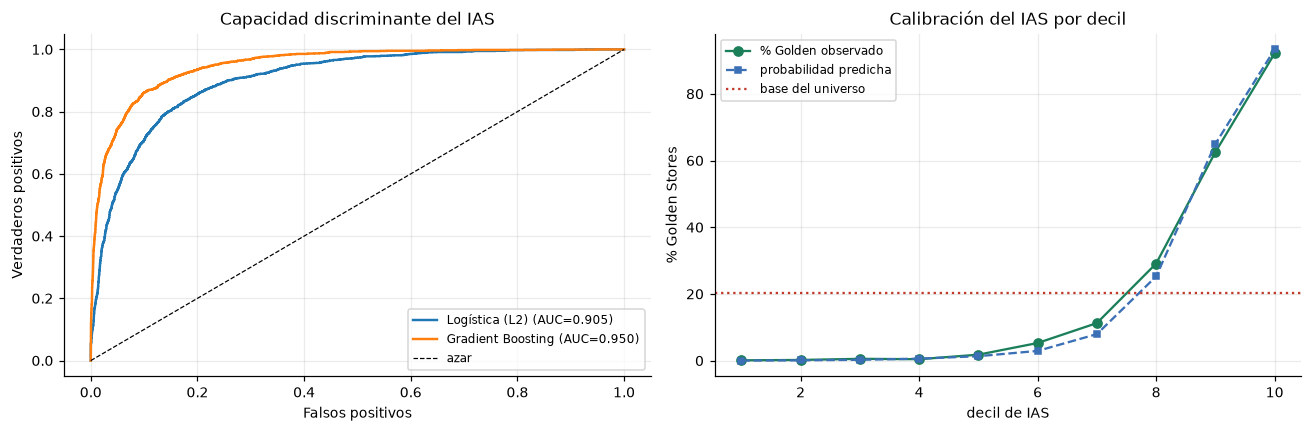

El decil superior de IAS concentra 92.1% de Golden Stores vs. 20.4% en el universo → lift de 4.5×


In [31]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
for nombre, pr in scores.items():
    fpr, tpr, _ = roc_curve(y, pr)
    a1.plot(fpr, tpr, lw=1.6, label=f"{nombre} (AUC={roc_auc_score(y, pr):.3f})")
a1.plot([0, 1], [0, 1], "k--", lw=.8, label="azar")
a1.set_xlabel("Falsos positivos"); a1.set_ylabel("Verdaderos positivos")
a1.set_title("Capacidad discriminante del IAS"); a1.legend(fontsize=8)

# Calibracion por decil: el score debe ordenar, no solo separar.
d = pd.DataFrame({"p": univ.p_golden, "y": y})
d["decil"] = pd.qcut(d.p, 10, labels=False, duplicates="drop") + 1
cal = d.groupby("decil").agg(predicho=("p", "mean"), observado=("y", "mean"), n=("y", "size"))
a2.plot(cal.index, cal.observado * 100, "o-", color="#1b7f5a", label="% Golden observado")
a2.plot(cal.index, cal.predicho * 100, "s--", color="#3b6fb6", ms=4, label="probabilidad predicha")
a2.axhline(y.mean() * 100, color="#c0392b", ls=":", label="base del universo")
a2.set_xlabel("decil de IAS"); a2.set_ylabel("% Golden Stores"); a2.legend(fontsize=8)
a2.set_title("Calibración del IAS por decil")
fig.tight_layout(); plt.show()

lift10 = cal.observado.iloc[-1] / y.mean()
print(f"El decil superior de IAS concentra {cal.observado.iloc[-1]*100:.1f}% de Golden Stores "
      f"vs. {y.mean()*100:.1f}% en el universo → lift de {lift10:.1f}×")

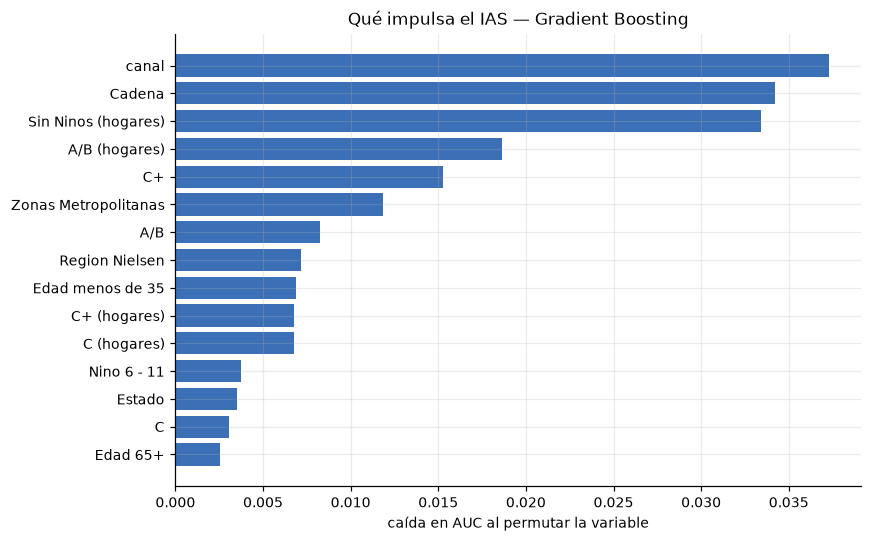

IAS = percentil nacional de la probabilidad de parecerse a una Golden Store (0–100).


In [32]:
# Que variables mueven el IAS (permutation importance sobre una particion held-out)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=.25, stratify=y, random_state=SEMILLA)
mod = modelos[mejor].fit(Xtr, ytr)
imp = permutation_importance(mod, Xte, yte, n_repeats=8, random_state=SEMILLA, scoring="roc_auc")

vi = pd.Series(imp.importances_mean, index=NUM + CAT).sort_values(ascending=False).head(15)[::-1]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh([i.replace("|Indice", "").replace("|HHs", " (hogares)") for i in vi.index],
        vi.values, color="#3b6fb6")
ax.set_xlabel("caída en AUC al permutar la variable")
ax.set_title(f"Qué impulsa el IAS — {mejor}")
fig.tight_layout(); plt.show()

univ["IAS"] = (univ.p_golden.rank(pct=True) * 100).round(1)
print("IAS = percentil nacional de la probabilidad de parecerse a una Golden Store (0–100).")

---
# 6 · Capa Scantrack: relevancia geográfica de la categoría

> **Paso 3 solicitado por el cliente.**

El archivo `Info Top Ciudades Industria RRS MX` trae el **mix de Autoservicios por ciudad** junto
con el embotellador responsable. Se usa como ponderador: una tienda con el mismo perfil pesa más si
está en una plaza que concentra más categoría.

In [33]:
ciu = pd.read_excel(DATA / "Info Top Ciudades Industria RRS MX.xlsx",
                    sheet_name="Segmentación Ciudades", header=1)
ciu.columns = ["embotellador", "ciudad", "mix_as", "tiendas_oxxo", "nota"][:len(ciu.columns)]
ciu = ciu.dropna(subset=["ciudad"])
ciu["ciudad"] = ciu.ciudad.astype(str).str.strip()
ciu = ciu[~ciu.ciudad.str.lower().eq("otras")]
ciu["embotellador"] = ciu.embotellador.ffill()
ciu["share_categoria"] = (ciu.mix_as / ciu.mix_as.sum() * 100).round(2)

print(f"{len(ciu)} ciudades con lectura Scantrack · mix AS cubierto: {ciu.mix_as.sum():.1f}%\n")
display(ciu.nlargest(15, "mix_as")[["embotellador", "ciudad", "mix_as", "share_categoria"]])

51 ciudades con lectura Scantrack · mix AS cubierto: 77.6%



,embotellador,ciudad,mix_as,share_categoria
0,KOF,VDM,22.5,28.99
1,AC,Monterrey,6.0,7.73
2,AC,Guadalajara,4.2,5.41
3,CDF,Tijuana,4.2,5.41
4,KOF,Puebla,2.3,2.96
5,KOF,Querétaro,1.9,2.45
6,AC,Culiacán,1.8,2.32
7,Bepensa,Cancún,1.8,2.32
8,AC,Chihuahua,1.8,2.32
9,AC,Los Cabos,1.5,1.93


In [34]:
# Puente ciudad Scantrack -> Zona Metropolitana Nielsen.
# Explicito a proposito: son dos nomenclaturas distintas, y un fuzzy match silencioso aqui
# es justo el tipo de error que nadie audita despues.
PUENTE = {
    "VDM": "VALLE DE MEXICO", "Guadalajara": "GUADALAJARA", "Monterrey": "MONTERREY",
    "Mérida": "MERIDA", "Cancún": "CANCUN", "Tijuana": "TIJUANA", "Puebla": "PUEBLA TLAXCALA",
    "Querétaro": "QUERETARO", "Culiacán": "CULIACAN", "Chihuahua": "CHIHUAHUA",
    "Veracruz": "VERACRUZ", "León ": "LEON", "SLP ": "SAN LUIS POTOSI", "Tampico": "TAMPICO",
    "Playa del Carmen": "PLAYA DEL CARMEN", "Torreón ": "LAGUNA", "Saltillo": "SALTILLO",
    "Mexicali": "MEXICALI", "Acapulco": "ACAPULCO", "Cuernavaca": "CUERNAVACA",
    "aguascalientes": "AGUASCALIENTES", "Hermosillo": "HERMOSILLO",
    "Puerto Vallarta": "PUERTO VALLARTA", "Villahermosa": "VILLAHERMOSA",
    "Mazatlán ": "MAZATLAN", "Durango": "DURANGO", "Tuxtla": "TUXTLA GUTIERREZ",
    "La Paz": "LA PAZ", "Xalapa": "XALAPA", "Oaxaca": "OAXACA", "Ensenada": "ENSENADA",
    "Reynosa": "REYNOSA", "Matamoros": "MATAMOROS", "Nogales": "NOGALES", "Tepic": "TEPIC",
    "Coatzacoalcos": "COATZACOALCOS", "Irapuato": "IRAPUATO", "Nuevo Laredo": "NUEVO LAREDO",
    "Orizaba": "ORIZABA", "Poza Rica": "POZA RICA", "Cozumel": "COZUMEL", "Campeche": "CAMPECHE",
    "Monclova": "MONCLOVA", "Los Cabos": "LOS CABOS", "Morelina": "MORELIA",
}
ciu["zm"] = ciu.ciudad.map(PUENTE)
zm_univ = set(univ["Zonas Metropolitanas"].dropna().unique())
enlazadas = ciu[ciu.zm.isin(zm_univ)]

print(f"Ciudades Scantrack enlazadas al universo Nielsen: {len(enlazadas)}/{len(ciu)} "
      f"({enlazadas.mix_as.sum()/ciu.mix_as.sum()*100:.0f}% del mix AS mapeado)")
print("\nSin enlace (no aparecen como ZM en el universo de tiendas):")
print("  " + ", ".join(sorted(set(ciu.ciudad) - set(enlazadas.ciudad))))

for zm in OPERACIONES:
    assert zm in set(enlazadas.zm), f"La plaza piloto {zm} no quedó enlazada a Scantrack"
print("\nLas 3 plazas piloto quedaron enlazadas ✔")

Ciudades Scantrack enlazadas al universo Nielsen: 28/51 (79% del mix AS mapeado)

Sin enlace (no aparecen como ZM en el universo de tiendas):
  Ahome, Campeche, Cd Obregon, Ciudad de Carmen, Cozumel, Culiacán, Delicias, Durango, Ensenada, Hermosillo, Irapuato, La Paz, León, Los Cabos, Mazatlán, Minatitlan, Monclova, Nogales, Piedras Negras, Playa del Carmen, Reynosa, SLP, Torreón

Las 3 plazas piloto quedaron enlazadas ✔


In [35]:
# Peso de ciudad normalizado 0-1 sobre el mix AS. Las plazas sin lectura Scantrack reciben
# el minimo observado, no cero: no tener lectura no es lo mismo que no tener categoria.
peso = enlazadas.groupby("zm").mix_as.max()
peso = (peso / peso.max()).clip(lower=.05)
MIN_PESO = peso.min()

univ["peso_ciudad"] = univ["Zonas Metropolitanas"].map(peso).fillna(MIN_PESO)
univ["embotellador"] = univ["Zonas Metropolitanas"].map(
    enlazadas.dropna(subset=["embotellador"]).drop_duplicates("zm").set_index("zm").embotellador)

cubiertos = univ["Zonas Metropolitanas"].isin(peso.index)
print(f"Peso de ciudad asignado · PDV en plaza con lectura Scantrack: {cubiertos.sum():,} "
      f"({cubiertos.mean()*100:.0f}% del universo); el resto recibe el piso {MIN_PESO:.2f}\n")
display(peso.sort_values(ascending=False).head(12).round(3).to_frame("peso_ciudad"))

Peso de ciudad asignado · PDV en plaza con lectura Scantrack: 4,278 (48% del universo); el resto recibe el piso 0.05



,peso_ciudad
zm,
VALLE DE MEXICO,1.000
MONTERREY,0.267
TIJUANA,0.187
GUADALAJARA,0.187
PUEBLA TLAXCALA,0.102
QUERETARO,0.084
CHIHUAHUA,0.080
CANCUN,0.080
MERIDA,0.067


---
# 7 · Score de Potencial y priorización

El potencial de una tienda es la conjunción de tres condiciones. Se combinan con una
**media geométrica ponderada**, no aritmética, precisamente porque son condiciones *conjuntas*:
una tienda con afinidad altísima pero en una plaza sin categoría no debería rescatarse con un
promedio. La media geométrica castiga el eslabón débil; la aritmética lo esconde.

$$\text{Potencial} = 100 \cdot \left( \text{IAS}^{\,w_a} \cdot \text{Brecha}^{\,w_b} \cdot \text{Peso ciudad}^{\,w_c} \right)$$

| Componente | Qué captura | Peso |
|---|---|---|
| **IAS** | El entorno se parece al de una Golden Store | 0.50 |
| **Brecha** | Esa demanda hoy **no** se está capturando (semáforo + eje de venta) | 0.30 |
| **Peso ciudad** | La plaza concentra categoría según Scantrack | 0.20 |

Los pesos son una decisión de negocio, no un resultado estadístico: están parametrizados en §0 y la
sensibilidad se prueba en §7.1.

In [36]:
# Brecha = demanda potencial no capturada. Combina el semaforo de la linea (granular)
# con el eje de venta del cluster (estructural, respaldo cuando no hay semaforo).
univ["desempeno_actual"] = univ.sem_sueros.map(ESCALA_SEMAFORO)
univ["desempeno_actual"] = univ.desempeno_actual.fillna(
    univ.venta_valor.map({"Alta": 1.0, "Baja": 0.0}))
univ["brecha"] = 1 - univ.desempeno_actual
univ["ias_n"] = univ.IAS / 100

def geom(df, comps, pesos):
    """Media geométrica ponderada; el piso evita que un cero anule la fila entera."""
    v = np.ones(len(df))
    for c, w in zip(comps, pesos):
        v *= np.clip(df[c].to_numpy(float), 1e-3, None) ** w
    return v

COMPS = ["ias_n", "brecha", "peso_ciudad"]
univ["potencial"] = geom(univ, COMPS, [W_AFINIDAD, W_BRECHA, W_CIUDAD])
univ["potencial"] = (univ.potencial / univ.potencial.max() * 100).round(1)

display(univ[["IAS", "brecha", "peso_ciudad", "potencial"]].describe().round(2))

,IAS,brecha,peso_ciudad,potencial
count,8864.00,8864.00,8864.00,8864.00
mean,50.01,0.53,0.19,29.38
std,28.87,0.36,0.31,20.21
min,0.00,0.00,0.05,0.20
25%,25.00,0.50,0.05,10.50
50%,50.00,0.50,0.05,28.80
75%,75.00,1.00,0.10,41.90
max,100.00,1.00,1.00,100.00


,PDV,IAS_medio,brecha_media,potencial_medio,% hoy Golden
prioridad,,,,,
P3,6206,39.6,0.5,19.0,7.2
P2,1769,72.2,0.7,45.4,45.9
P1,889,78.5,0.7,69.8,61.6


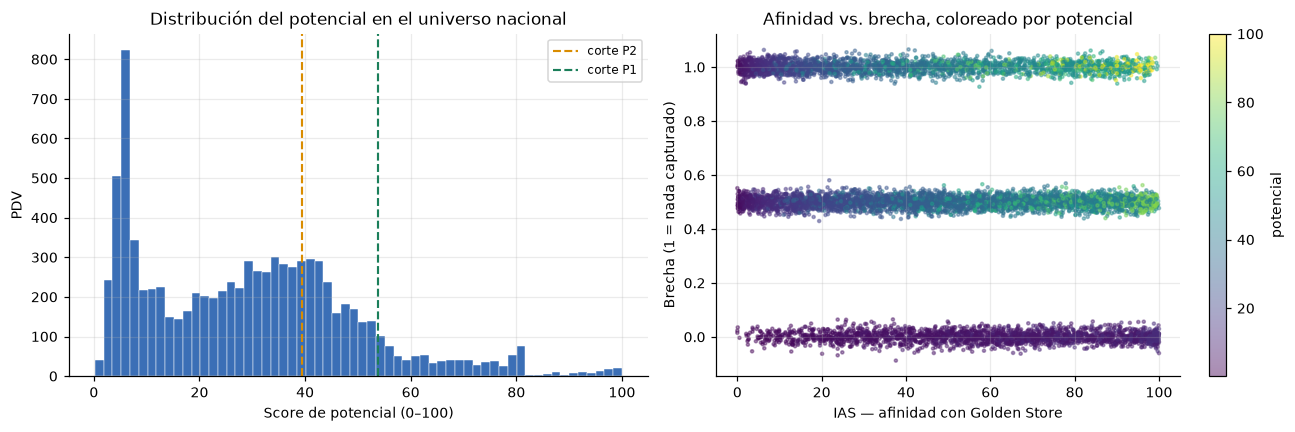

In [37]:
# Prioridad P1/P2/P3 sobre el universo nacional, replicando la nomenclatura del ejercicio FARGUA.
univ["prioridad"] = pd.cut(univ.potencial.rank(pct=True), [0, .70, .90, 1.0],
                           labels=["P3", "P2", "P1"], include_lowest=True)

display(univ.groupby("prioridad", observed=True).agg(
    PDV=("Nielsen ID", "count"), IAS_medio=("IAS", "mean"),
    brecha_media=("brecha", "mean"), potencial_medio=("potencial", "mean"),
    **{"% hoy Golden": ("es_golden", lambda s: s.mean() * 100)}).round(1))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.hist(univ.potencial, bins=60, color="#3b6fb6", edgecolor="white", linewidth=.3)
for q, lab, col in [(.70, "P2", "#d98c00"), (.90, "P1", "#1b7f5a")]:
    a1.axvline(univ.potencial.quantile(q), color=col, ls="--", lw=1.4, label=f"corte {lab}")
a1.set_xlabel("Score de potencial (0–100)"); a1.set_ylabel("PDV"); a1.legend(fontsize=8)
a1.set_title("Distribución del potencial en el universo nacional")

jit = np.random.default_rng(SEMILLA).normal(0, .02, len(univ))
sc = a2.scatter(univ.IAS, univ.brecha + jit, c=univ.potencial, cmap="viridis", s=4, alpha=.45)
a2.set_xlabel("IAS — afinidad con Golden Store"); a2.set_ylabel("Brecha (1 = nada capturado)")
a2.set_title("Afinidad vs. brecha, coloreado por potencial")
plt.colorbar(sc, ax=a2, label="potencial")
fig.tight_layout(); plt.show()

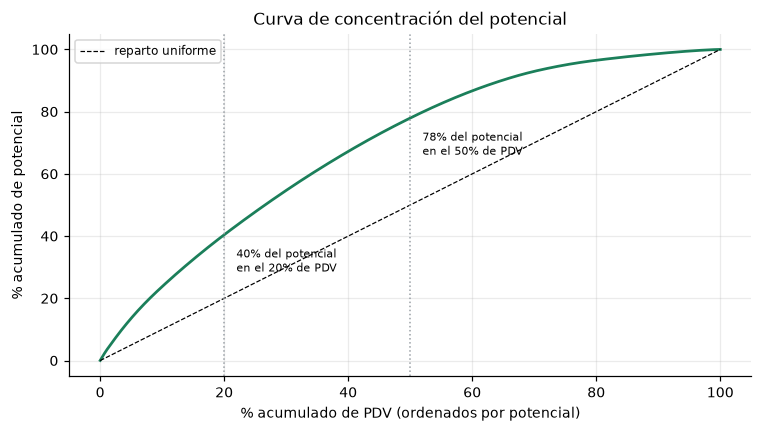

In [38]:
# Concentracion tipo Pareto (retail-math-eda §4D, adaptado: potencial en lugar de ingreso).
pot = univ.potencial.sort_values(ascending=False)
acum = pot.cumsum() / pot.sum() * 100
pct_pdv = np.arange(1, len(pot) + 1) / len(pot) * 100
univ["clase_ABC"] = pd.qcut(univ.potencial.rank(pct=True, ascending=False),
                            [0, .20, .50, 1.0], labels=["A", "B", "C"])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(pct_pdv, acum, color="#1b7f5a", lw=1.8)
ax.plot([0, 100], [0, 100], "k--", lw=.8, label="reparto uniforme")
for x in (20, 50):
    yv = acum.iloc[int(len(pot) * x / 100) - 1]
    ax.axvline(x, color="#9aa0a6", ls=":", lw=1)
    ax.annotate(f"{yv:.0f}% del potencial\nen el {x}% de PDV", (x, yv),
                textcoords="offset points", xytext=(8, -24), fontsize=7.5)
ax.set_xlabel("% acumulado de PDV (ordenados por potencial)")
ax.set_ylabel("% acumulado de potencial"); ax.legend(fontsize=8)
ax.set_title("Curva de concentración del potencial")
fig.tight_layout(); plt.show()

### 7.1 · Sensibilidad a los pesos

In [39]:
# Si el ranking se da vuelta al mover los pesos, el ranking no es un hallazgo: es una eleccion.
ESCENARIOS = {
    "Base (.50/.30/.20)":            (.50, .30, .20),
    "Afinidad pura (.80/.10/.10)":   (.80, .10, .10),
    "Brecha pesada (.30/.50/.20)":   (.30, .50, .20),
    "Geografía pesada (.40/.20/.40)": (.40, .20, .40),
    "Equitativo (1/3 c/u)":          (1/3, 1/3, 1/3),
}
N_TOP = 500
base_top = set(univ.nlargest(N_TOP, "potencial")["Nielsen ID"])
sens = []
for nombre, w in ESCENARIOS.items():
    s = geom(univ, COMPS, w)
    top = set(univ.assign(_s=s).nlargest(N_TOP, "_s")["Nielsen ID"])
    sens.append((nombre, len(top & base_top) / N_TOP * 100,
                 stats.spearmanr(s, univ.potencial).statistic))
sens = pd.DataFrame(sens, columns=["escenario", f"% overlap top-{N_TOP} vs. base",
                                   "ρ Spearman vs. base"])
display(sens.round(3))
print("Overlap alto y ρ > 0.9 significan que el ranking es robusto: los pesos afinan el orden,\n"
      "no lo deciden. Si un escenario cayera por debajo de ~60% de overlap, ese peso sería una\n"
      "decisión de negocio a validar explícitamente antes de ejecutar.")

,escenario,% overlap top-500 vs. base,ρ Spearman vs. base
0,Base (.50/.30/.20),99.8,1.000
1,Afinidad pura (.80/.10/.10),79.8,0.835
2,Brecha pesada (.30/.50/.20),87.0,0.970
3,Geografía pesada (.40/.20/.40),84.2,0.945
4,Equitativo (1/3 c/u),84.2,0.975


Overlap alto y ρ > 0.9 significan que el ranking es robusto: los pesos afinan el orden,
no lo deciden. Si un escenario cayera por debajo de ~60% de overlap, ese peso sería una
decisión de negocio a validar explícitamente antes de ejecutar.


---
## 7.2 · Resultado por operación piloto

In [40]:
piloto = univ[univ["Zonas Metropolitanas"].isin(OPERACIONES)].copy()
piloto["operacion"] = piloto["Zonas Metropolitanas"].map(OPERACIONES)

# Re-ranking DENTRO de cada plaza: cada embotellador prioriza contra su propio universo,
# no contra el nacional (si no, Merida nunca competiria contra VDM por tamano de plaza).
piloto["potencial_local"] = piloto.groupby("operacion").potencial.rank(pct=True).mul(100).round(1)
piloto["prioridad_local"] = piloto.groupby("operacion", group_keys=False).potencial.apply(
    lambda s: pd.cut(s.rank(pct=True), [0, .70, .90, 1.0],
                     labels=["P3", "P2", "P1"], include_lowest=True))

resumen_op = piloto.groupby("operacion").agg(
    PDV=("Nielsen ID", "count"), golden_hoy=("es_golden", "sum"),
    IAS_medio=("IAS", "mean"), brecha_media=("brecha", "mean"),
    peso_ciudad=("peso_ciudad", "first"), potencial_medio=("potencial", "mean")).round(2)
resumen_op["P1_local"] = piloto[piloto.prioridad_local.eq("P1")].groupby("operacion").size()
display(resumen_op)

,PDV,golden_hoy,IAS_medio,brecha_media,peso_ciudad,potencial_medio,P1_local
operacion,,,,,,,
Arca Continental — Guadalajara,277,107,66.19,0.52,0.19,38.93,28
Bepensa — Mérida,214,47,54.04,0.59,0.07,30.91,22
KOF — Ciudad de México,1103,390,62.25,0.45,1.00,47.18,112


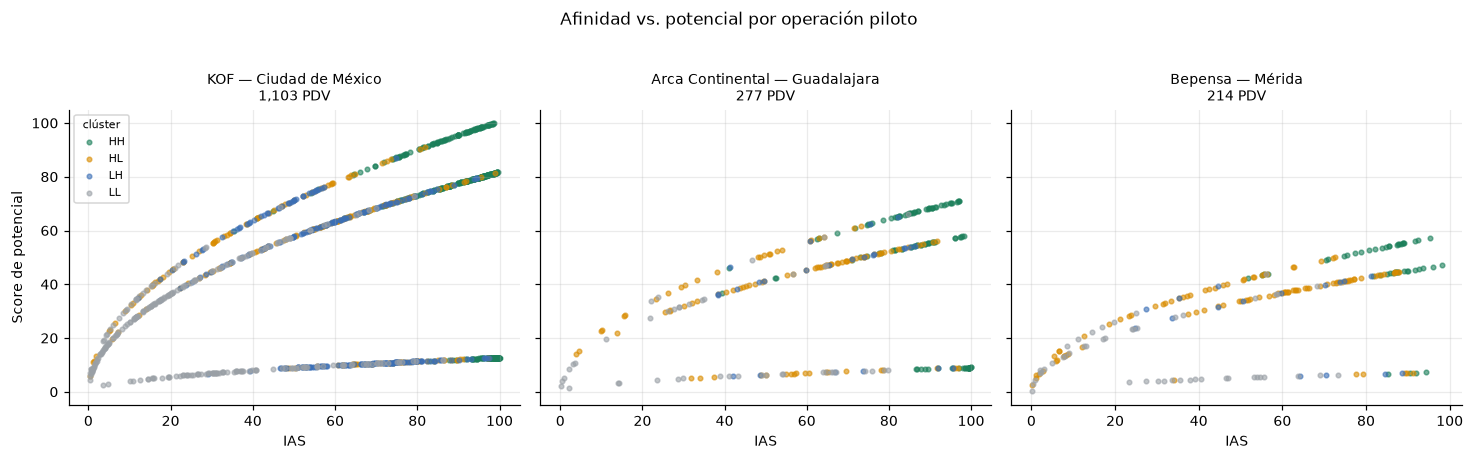

In [41]:
fig, ax = plt.subplots(1, 3, figsize=(13.5, 4), sharey=True)
for a, (zm, op) in zip(ax, OPERACIONES.items()):
    d = piloto[piloto.operacion == op]
    for cl in ["HH", "HL", "LH", "LL"]:
        s = d[d.Cluster == cl]
        a.scatter(s.IAS, s.potencial, s=9, alpha=.6, color=PAL[cl], label=cl)
    a.set_title(f"{op}\n{len(d):,} PDV", fontsize=9); a.set_xlabel("IAS")
ax[0].set_ylabel("Score de potencial")
ax[0].legend(title="clúster", fontsize=7, title_fontsize=7)
fig.suptitle("Afinidad vs. potencial por operación piloto", y=1.03)
fig.tight_layout(); plt.show()

In [42]:
COLS_SALIDA = [c for c in ["Nielsen ID", "Store Name", "Cadena", "canal", "Cluster", "sem_sueros",
               "IAS", "brecha", "peso_ciudad", "potencial", "potencial_local", "prioridad_local",
               "clase_ABC", "entorno_atipico", "Direccion", "Colonia", "Codigo Postal",
               "Municipio", "Localidad", "Zonas Metropolitanas", "Estado", "Latitud", "Longitud"]
               if c in piloto.columns]

for op in OPERACIONES.values():
    d = piloto[piloto.operacion == op].nlargest(10, "potencial_local")
    print(f"\n{'='*104}\nTOP 10 — {op}\n{'='*104}")
    display(d[["Store Name", "Cadena", "Cluster", "sem_sueros", "IAS", "brecha",
               "potencial_local", "Municipio", "Colonia"]].round(1).reset_index(drop=True))


TOP 10 — KOF — Ciudad de México


,Store Name,Cadena,Cluster,sem_sueros,IAS,brecha,potencial_local,Municipio,Colonia
0,F.AHORRO MXBB BALBUENA - 201903051488X0,FARMACIAS - DEL AHORRO,HH,ROJO,98.6,1.0,100.0,Venustiano Carranza (DF),JARDIN BALBUENA
1,WALMART SC - PLAZA DEL LAGO - 15121039X0,WAL-MART,HH,ROJO,98.4,1.0,99.9,Cuautitlán Izcalli (MEX),CENTRO
2,F.AHORRO VAQUERITOS - 201903050395X0,FARMACIAS - DEL AHORRO,HH,ROJO,98.2,1.0,99.8,Xochimilco (DF),SAN LORENZO LA CEBADA
3,CHEDRAUI MEXICO XOCHIMILCO - 9013007X0,CHEDRAUI,HH,ROJO,98.3,1.0,99.8,Xochimilco (DF),LA CONCHA
4,F.AHORRO MIRAMONTE - 201903050247X0,FARMACIAS - DEL AHORRO,HH,ROJO,98.0,1.0,99.6,Coyoacán (DF),JARDINES DE COYOACAN
5,WALMART SC - PERINORTE - 15121094X0,WAL-MART,HH,ROJO,98.1,1.0,99.6,Cuautitlán Izcalli (MEX),SAN MARTIN TEPETLIXPAN
6,BODEGA AURRERA - FF CC HIDALGO - 9005008X0,BODEGA AURRERA,HH,ROJO,97.8,1.0,99.5,Gustavo A. Madero (DF),ESTRELLA
7,F. AHORRO MXC7 CAMINO REAL - 201903051085X0,FARMACIAS - DEL AHORRO,HH,ROJO,97.4,1.0,99.3,Coyoacán (DF),SAN PABLO TEPETLAPA
8,BODEGA AURRERA - SANTA LUCIA - 9010040X1,BODEGA AURRERA,HH,ROJO,97.5,1.0,99.3,Álvaro Obregón (DF),ALFONSO XIII
9,F. AHORRO POLANCO - 2021032300002X0,FARMACIAS - DEL AHORRO,HH,ROJO,97.3,1.0,99.1,Miguel Hidalgo (DF),MIGUEL HIDALGO



TOP 10 — Arca Continental — Guadalajara


,Store Name,Cadena,Cluster,sem_sueros,IAS,brecha,potencial_local,Municipio,Colonia
0,F.AHORRO GUADALAJARA LAPIZLAZULLI - 2019030509...,FARMACIAS - DEL AHORRO,HH,ROJO,97.0,1.0,99.6,Guadalajara (JAL),SIN COLONIA
1,F. AHORRO GDGU GUADALUPE Y PATRIA - 2019030517...,FARMACIAS - DEL AHORRO,HH,ROJO,97.0,1.0,99.6,Zapopan (JAL),JARDINES DE GUADALUPE
2,F.AHORRO GUADALAJARA NARANJITOS - 201903050964X0,FARMACIAS - DEL AHORRO,HH,ROJO,96.9,1.0,99.6,Guadalajara (JAL),BOSQUES DE LA VICTORIA
3,F.AHORRO GDDK CHARLES DICKENS - 201903050886X0,FARMACIAS - DEL AHORRO,HH,ROJO,96.7,1.0,98.9,Zapopan (JAL),JARDINES VALLARTA
4,F.AHORRO GUADALAJARA VILLA CALIFORNIA - 201903...,FARMACIAS - DEL AHORRO,HH,ROJO,95.3,1.0,98.6,Tlajomulco de Zúñiga (JAL),SAN AGUSTIN
5,F.AHORRO GDMX AV MEXICO - 201903050883X0,FARMACIAS - DEL AHORRO,HH,ROJO,95.2,1.0,98.2,Zapopan (JAL),SIN COLONIA
6,F.AHORRO VALLARTA - 201903050855X0,FARMACIAS - DEL AHORRO,HH,ROJO,94.8,1.0,97.8,Zapopan (JAL),GRANJA
7,F. AHORRO LAZARO CARDENAS - 201903051245X0,FARMACIAS - DEL AHORRO,HH,ROJO,94.0,1.0,97.5,Zapopan (JAL),JARDIN DE SAN IGNACIO
8,F. AHORRO LOS FRAYLES - 201903051208X0,FARMACIAS - DEL AHORRO,HH,ROJO,93.4,1.0,97.1,Zapopan (JAL),LOMAS DEL BOSQUE (PUERTA DE HIERRO)
9,F.AHORRO GUADALAJARA MANUEL ACU?A - 2019030508...,FARMACIAS - DEL AHORRO,HH,ROJO,92.8,1.0,96.8,Guadalajara (JAL),ITALIA PROVIDENCIA



TOP 10 — Bepensa — Mérida


,Store Name,Cadena,Cluster,sem_sueros,IAS,brecha,potencial_local,Municipio,Colonia
0,CHEDRAUI MERIDA POLIGONO - 31050461X0,CHEDRAUI,HH,ROJO,95.4,1.0,100.0,Mérida (YUC),ITZIMNA
1,WALMART SC - POLIGONOS - 31050463X0,WAL-MART,HH,ROJO,92.5,1.0,99.5,Mérida (YUC),FRACCIONAMIENTO ITZIMNA
2,F. AHORRO JUAREZ NORTE - 201903051116X0,FARMACIAS - DEL AHORRO,HH,ROJO,91.8,1.0,99.1,Mérida (YUC),BENITO JUAREZ NORTE
3,FARMACON YZA 42 SUR - 201903052205X0,FARMACIAS - FARMACON,HH,ROJO,89.1,1.0,98.6,Mérida (YUC),FRACC MULSAY 1RA SECC
4,FARMACON YZA CONKAL - 201903052158X0,FARMACIAS - FARMACON,HH,ROJO,88.8,1.0,97.9,Conkal (YUC),SUPMZ 27
5,CHEDRAUI MERIDA CAUCEL - 31050057X0,CHEDRAUI,HH,ROJO,88.8,1.0,97.9,Mérida (YUC),SIN COLONIA
6,FARMACON YZA CD INDUSTRIAL - 201903052154X0,FARMACIAS - FARMACON,HH,ROJO,88.3,1.0,97.2,Mérida (YUC),CHUBURNA DE HIDALGO
7,FARMACON YZA CAUCEL NVA CREACION - 201903052149X0,FARMACIAS - FARMACON,HH,ROJO,87.9,1.0,96.5,Mérida (YUC),NUEVA MULSAY
8,F. AHORRO MEGS GRAN SAN PEDRO CHOLUL - 2023270...,FARMACIAS - DEL AHORRO,HH,ROJO,87.7,1.0,96.5,Mérida (YUC),GRAN SAN PEDRO CHOLUL
9,FARMACON YZA UMAN I - 201903052203X0,FARMACIAS - FARMACON,HH,ROJO,87.3,1.0,95.8,Umán (YUC),YUCATAN


---
# 8 · Síntesis ejecutiva y exportables

> *retail-math-eda §6 — cada recomendación con el estadístico que la sostiene, su incertidumbre,
> y el supuesto que la tumbaría si fuera falso.*

In [43]:
print("=" * 96)
print("SÍNTESIS — POTENCIAL DE PDV, CATEGORÍA SUEROS".center(96))
print("=" * 96)
print(f"""
UNIVERSO
  {len(univ):,} PDV consolidados de 3 fuentes Golden Stores FY'23 ({univ.canal.nunique()} canales,
  {univ.Cadena.nunique()} cadenas, {univ['Zonas Metropolitanas'].nunique()} zonas metropolitanas).
  Golden Stores actuales (clúster HH): {univ.es_golden.sum():,} ({univ.es_golden.mean()*100:.1f}%).

MODELO BASE  (paso 1)
  El eje de demanda del archivo queda validado contra los datos socio-demográficos:
  {int((val.q_BH < .05).sum())}/{len(val)} índices separan demanda Alta de Baja con q<0.05 (BH-FDR).
  Cuadrante de mayor oportunidad estructural — HL, alta demanda y baja venta:
  {int((univ.Cluster == 'HL').sum()):,} PDV ({(univ.Cluster == 'HL').mean()*100:.0f}% del universo).

PERFIL GOLDEN  (paso 2)
  Sobre-indexan: {', '.join(perfil.head(3).variable)}.
  Sub-indexan:   {', '.join(perfil.tail(3).variable)}.
  IAS: AUC-ROC {roc_auc_score(y, univ.p_golden):.3f} bajo CV estratificada de 5 pliegues.
  El decil superior de IAS concentra {lift10:.1f}× más Golden Stores que la base del universo.

CAPA GEOGRÁFICA  (paso 3)
  {len(enlazadas)} ciudades Scantrack enlazadas, {enlazadas.mix_as.sum()/ciu.mix_as.sum()*100:.0f}% del mix AS mapeado.
  Peso relativo de las plazas piloto — VDM {peso.get('VALLE DE MEXICO', np.nan):.2f} ·
  Guadalajara {peso.get('GUADALAJARA', np.nan):.2f} · Mérida {peso.get('MERIDA', np.nan):.2f}.

PRIORIZACIÓN
  {len(piloto):,} PDV en las tres operaciones piloto.
  P1 local (decil superior de cada plaza): {int(piloto.prioridad_local.eq('P1').sum()):,} PDV.
  El 20% superior por potencial concentra {acum.iloc[int(len(pot)*.2)-1]:.0f}% del potencial total.
  Ranking robusto a los pesos: overlap mínimo del top-{N_TOP} entre escenarios =
  {sens.iloc[:, 1].min():.0f}%.
""")
print("=" * 96)

                         SÍNTESIS — POTENCIAL DE PDV, CATEGORÍA SUEROS                          

UNIVERSO
  8,864 PDV consolidados de 3 fuentes Golden Stores FY'23 (2 canales,
  39 cadenas, 60 zonas metropolitanas).
  Golden Stores actuales (clúster HH): 1,804 (20.4%).

MODELO BASE  (paso 1)
  El eje de demanda del archivo queda validado contra los datos socio-demográficos:
  20/20 índices separan demanda Alta de Baja con q<0.05 (BH-FDR).
  Cuadrante de mayor oportunidad estructural — HL, alta demanda y baja venta:
  2,183 PDV (25% del universo).

PERFIL GOLDEN  (paso 2)
  Sobre-indexan: C+, A/B, Edad 45 - 54.
  Sub-indexan:   Edad menos de 35, D+, D/E.
  IAS: AUC-ROC 0.950 bajo CV estratificada de 5 pliegues.
  El decil superior de IAS concentra 4.5× más Golden Stores que la base del universo.

CAPA GEOGRÁFICA  (paso 3)
  28 ciudades Scantrack enlazadas, 79% del mix AS mapeado.
  Peso relativo de las plazas piloto — VDM 1.00 ·
  Guadalajara 0.19 · Mérida 0.07.

PRIORIZACIÓN
  1,594 P

In [44]:
for op in OPERACIONES.values():
    d = piloto[piloto.operacion == op]
    p1 = d[d.prioridad_local.eq("P1")]
    cad = p1.Cadena.value_counts().head(3)
    mun = p1.Municipio.value_counts().head(3)
    hl = int(p1.Cluster.eq("HL").sum())
    print(f"\n▌ {op}")
    print(f"  Universo piloto     : {len(d):,} PDV · Golden hoy: {d.es_golden.sum():,} "
          f"({d.es_golden.mean()*100:.0f}%)")
    print(f"  P1 a activar        : {len(p1):,} PDV (IAS medio {p1.IAS.mean():.0f}, "
          f"brecha media {p1.brecha.mean():.2f})")
    print(f"  Cadenas a priorizar : {', '.join(f'{k} ({v})' for k, v in cad.items())}")
    print(f"  Municipios foco     : {', '.join(f'{k} ({v})' for k, v in mun.items())}")
    print(f"  De los P1, {hl} son HL — alta demanda ya medida y venta baja: la conversión más corta.")


▌ KOF — Ciudad de México
  Universo piloto     : 1,103 PDV · Golden hoy: 390 (35%)
  P1 a activar        : 112 PDV (IAS medio 88, brecha media 0.95)
  Cadenas a priorizar : FARMACIAS - DEL AHORRO (42), BODEGA AURRERA (23), WAL-MART (16)
  Municipios foco     : Álvaro Obregón (DF) (10), Iztapalapa (DF) (8), Naucalpan de Juárez (MEX) (8)
  De los P1, 5 son HL — alta demanda ya medida y venta baja: la conversión más corta.

▌ Arca Continental — Guadalajara
  Universo piloto     : 277 PDV · Golden hoy: 107 (39%)
  P1 a activar        : 28 PDV (IAS medio 91, brecha media 1.00)
  Cadenas a priorizar : FARMACIAS - DEL AHORRO (24), BODEGA AURRERA (1), CHEDRAUI (1)
  Municipios foco     : Zapopan (JAL) (16), Guadalajara (JAL) (7), San Pedro Tlaquepaque (JAL) (3)
  De los P1, 0 son HL — alta demanda ya medida y venta baja: la conversión más corta.

▌ Bepensa — Mérida
  Universo piloto     : 214 PDV · Golden hoy: 47 (22%)
  P1 a activar        : 22 PDV (IAS medio 84, brecha media 1.00)
  Cadenas

In [45]:
ruta = OUT / "priorizacion_sueros_pdv.xlsx"
with pd.ExcelWriter(ruta, engine="xlsxwriter") as w:
    resumen_op.to_excel(w, sheet_name="Resumen operaciones")
    for zm, op in OPERACIONES.items():
        (piloto[piloto.operacion == op].sort_values("potencial_local", ascending=False)
         [COLS_SALIDA].to_excel(w, sheet_name=zm[:31], index=False))
    perfil.round(4).to_excel(w, sheet_name="Perfil Golden", index=False)
    lift_categorico("Cadena").to_excel(w, sheet_name="Lift por cadena")
    sens.round(4).to_excel(w, sheet_name="Sensibilidad pesos", index=False)
    (univ.sort_values("potencial", ascending=False)
     [[c for c in COLS_SALIDA if c in univ.columns]]
     .to_excel(w, sheet_name="Universo nacional", index=False))

piloto.sort_values("potencial_local", ascending=False).to_csv(
    OUT / "priorizacion_sueros_piloto.csv", index=False, encoding="utf-8-sig")

print(f"✔ {ruta.name}  ({ruta.stat().st_size/1e6:.1f} MB)")
print(f"✔ priorizacion_sueros_piloto.csv  ({len(piloto):,} PDV)")
print(f"  en {OUT}")

✔ priorizacion_sueros_pdv.xlsx  (1.5 MB)
✔ priorizacion_sueros_piloto.csv  (1,594 PDV)
  en c:\Users\KIN\Desktop\Kin\eda_data\outputs


---
## Supuestos que tumbarían este análisis si fueran falsos

1. **`Cluster == "HH"` es la definición correcta de Golden Store.** Sale de la metodología FY'23 de
   los entregables. Si el negocio usa otro corte (p. ej. HH + LH con semáforo verde), `es_golden`
   cambia y con él todo el IAS. Es una línea de código, pero hay que decidirla explícitamente.

2. **El semáforo es un proxy válido de venta capturada.** Es ordinal en tres niveles. Con ventas
   valor por tienda, `brecha` pasaría de ordinal a continua y el ranking ganaría resolución real —
   es la mejora de mayor impacto disponible.

3. **El área transaccional Spectra no se movió desde FY'23.** Aperturas, cierres y remodelaciones de
   competencia alteran el polígono. Con más de un año de antigüedad, conviene refrescar.

4. **El mix AS de Scantrack representa la categoría Sueros específicamente.** Si el mix del archivo
   es de la canasta RRS total y no de Sueros, `peso_ciudad` está midiendo relevancia de bebidas en
   general. **Vale la pena confirmarlo con el equipo de Scantrack antes de ejecutar**: es el supuesto
   más frágil de los cuatro y el más barato de verificar.

## Qué agregaría más valor a continuación

| Fuente | Qué desbloquea |
|---|---|
| **Ventas valor por tienda/periodo** | Brecha continua, elasticidad, ABC-XYZ real, detección de quiebres |
| **POIs (movilidad y entretenimiento)** | Ya probado en el ejercicio FARGUA; separa tráfico de residencial |
| **Saturación de competencia por polígono** | Existe para farmacias; extenderlo a autoservicios |
| **Sell-out / distribución numérica** | Distinguir "no vende" de "no está listado" — hoy se confunden |